# Laporan Praktikum Machine Learning
## Pertemuan 2: Data Preprocessing dan Exploratory Data Analysis (EDA)

* **Nama**: Ardian Syaputra
* **NIM**: 105841107823

---

## 🛠️ Setup Environment & Import Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

# Setting style visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Library berhasil di-import!")

Library berhasil di-import!


---
## 📌 Tugas 1: Data Cleaning 
Proses identifikasi, visualisasi, dan penanganan missing values serta data duplikat pada dataset Titanic.

In [3]:
# 1. Load Dataset
df = sns.load_dataset('titanic')

# Informasi Dasar
print("=== Ukuran Dataset ===")
print(f"Jumlah Baris : {df.shape[0]}")
print(f"Jumlah Kolom : {df.shape[1]}\n")

print("=== Tipe Data Tiap Kolom ===")
print(df.dtypes)

print("\n=== 5 Baris Pertama ===")
display(df.head())

=== Ukuran Dataset ===
Jumlah Baris : 891
Jumlah Kolom : 15

=== Tipe Data Tiap Kolom ===
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

=== 5 Baris Pertama ===


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Task 1.1: Load & Inspeksi Data

=== Jumlah Missing Values ===
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


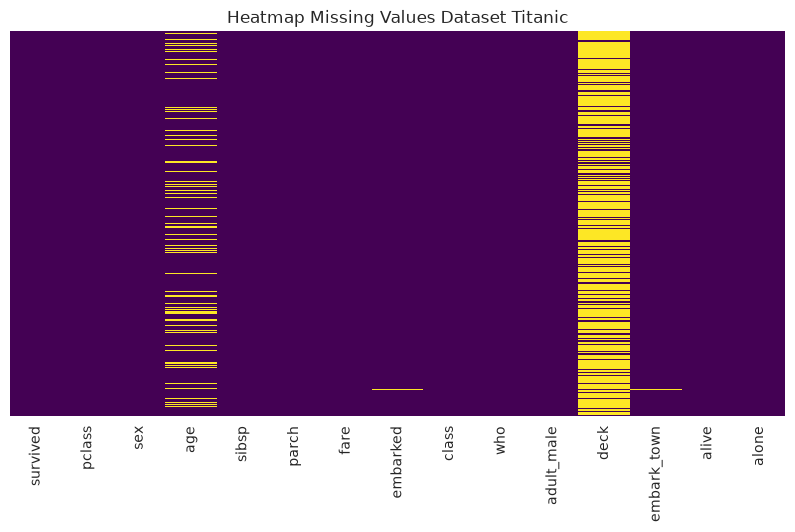

In [4]:
# Cek Jumlah Missing Values per Kolom
missing_series = df.isnull().sum()
print("=== Jumlah Missing Values ===")
print(missing_series[missing_series > 0])

# Visualisasi Heatmap Missing Values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Heatmap Missing Values Dataset Titanic')
plt.show()

Task 1.3: Handling Missing Values (3 Strategi)


In [5]:
# Strategi 1: Drop Kolom/Baris yang Memiliki Missing Value Terlalu Banyak (Deck)
df_strat1 = df.copy()
df_strat1 = df_strat1.drop(columns=['deck'])  # Kolom deck memiliki >70% missing value

# Strategi 2: Imputasi Nilai Kategorikal dengan Modus (Embarked & Embark_town)
df_strat2 = df_strat1.copy()
mode_embarked = df_strat2['embarked'].mode()[0]
mode_town = df_strat2['embark_town'].mode()[0]

df_strat2['embarked'] = df_strat2['embarked'].fillna(mode_embarked)
df_strat2['embark_town'] = df_strat2['embark_town'].fillna(mode_town)

# Strategi 3: Imputasi Nilai Numerik Menggunakan SimpleImputer Median (Age)
imputer_median = SimpleImputer(strategy='median')
df_strat2['age'] = imputer_median.fit_transform(df_strat2[['age']])

print("=== Total Missing Values Setelah Handling ===")
print(df_strat2.isnull().sum().sum())

=== Total Missing Values Setelah Handling ===
0


Task 1.4: Handling Duplicates

In [6]:
# Cek Jumlah Duplikat
num_duplicates = df_strat2.duplicated().sum()
print(f"Jumlah Baris Duplikat Awal: {num_duplicates}")

# Remove Duplikat
df_cleaned = df_strat2.drop_duplicates()
print(f"Jumlah Baris Setelah Hapus Duplikat: {df_cleaned.shape[0]}")

Jumlah Baris Duplikat Awal: 116
Jumlah Baris Setelah Hapus Duplikat: 775


### 📝 Dokumentasi Keputusan Data Cleaning:
1. **Kolom `deck` dihapus** karena persentase data hilang mencapai lebih dari 75%, sehingga imputasi akan memberikan bias yang terlalu tinggi.
2. **Kolom `embarked` dan `embark_town` diimputasi dengan Modus** karena bertipe kategorikal dan hanya memiliki 2 baris hilang.
3. **Kolom `age` diimputasi dengan Median** menggunakan `SimpleImputer` karena distribusi umur cenderung *skewed* (mempunyai *outliers*).
4. **Data Duplikat dihapus** untuk menghindari *overfitting* atau bobot ganda pada sampel data yang sama saat modeling.

---
## 📌 Tugas 2: Outlier Detection dan Handling (25 Poin)
Deteksi dan penanganan data pencilan (*outliers*) menggunakan metode Interquartile Range (IQR) pada 3 kolom numerik: `age`, `fare`, dan `sibsp`.

Task 2.1 & 2.2: Deteksi Outliers IQR pada 3 Kolom

In [7]:
# Pilih 3 kolom numerik untuk dianalisis
num_cols = ['age', 'fare', 'sibsp']

# Fungsi Deteksi Outliers dengan IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Tampilkan informasi outliers untuk tiap kolom
for col in num_cols:
    outliers, lower, upper = detect_outliers_iqr(df_cleaned, col)
    print(f"=== Outliers Kolom '{col}' ===")
    print(f"Jumlah Outliers : {len(outliers)}")
    print(f"Batas Bawah     : {lower:.2f}")
    print(f"Batas Atas      : {upper:.2f}\n")

=== Outliers Kolom 'age' ===
Jumlah Outliers : 27
Batas Bawah     : -1.50
Batas Atas      : 58.50

=== Outliers Kolom 'fare' ===
Jumlah Outliers : 102
Batas Bawah     : -31.17
Batas Atas      : 73.42

=== Outliers Kolom 'sibsp' ===
Jumlah Outliers : 39
Batas Bawah     : -1.50
Batas Atas      : 2.50



Task 2.3: Visualisasi Boxplot Sebelum Handling

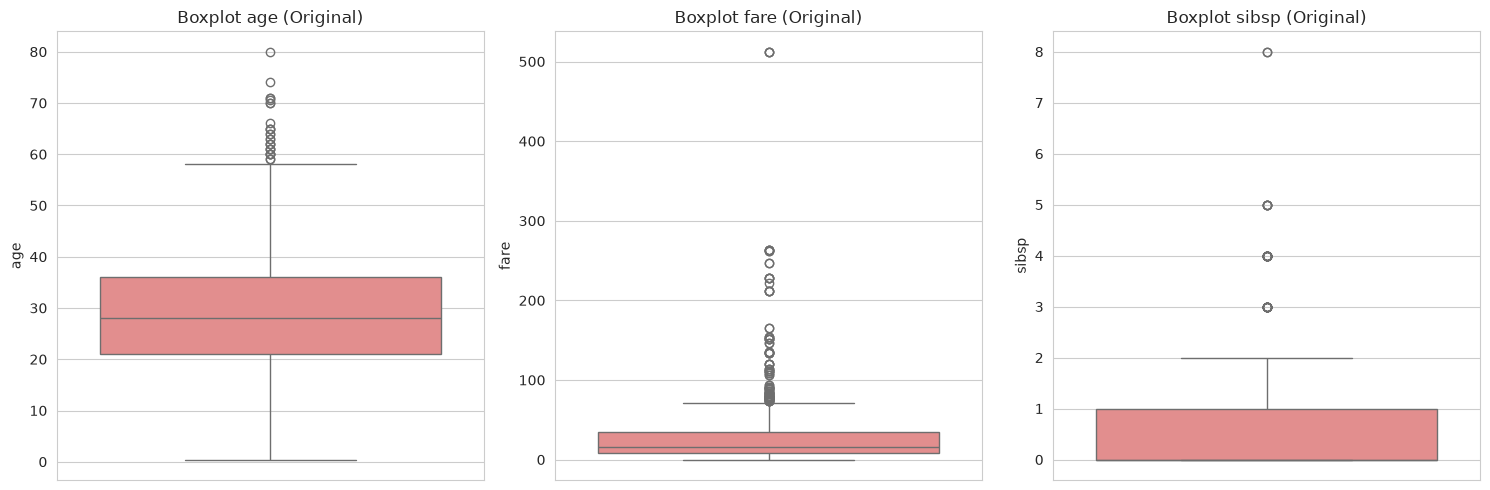

In [8]:
# Visualisasi Boxplot Sebelum Handling (Original Data)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, col in enumerate(num_cols):
    sns.boxplot(y=df_cleaned[col], ax=axes[idx], color='lightcoral')
    axes[idx].set_title(f'Boxplot {col} (Original)')

plt.tight_layout()
plt.show()

Task 2.4a: Implementasi Metode Removal


In [9]:
# Metode 2: Removal (Menghapus baris yang mengandung outlier)
df_removed = df_cleaned.copy()

for col in num_cols:
    outliers, lower, upper = detect_outliers_iqr(df_removed, col)
    df_removed = df_removed[(df_removed[col] >= lower) & (df_removed[col] <= upper)]

print(f"Jumlah baris sebelum removal : {len(df_cleaned)}")
print(f"Jumlah baris setelah removal : {len(df_removed)}")

Jumlah baris sebelum removal : 775
Jumlah baris setelah removal : 613


Task 2.4a: Implementasi Metode Capping/Clipping

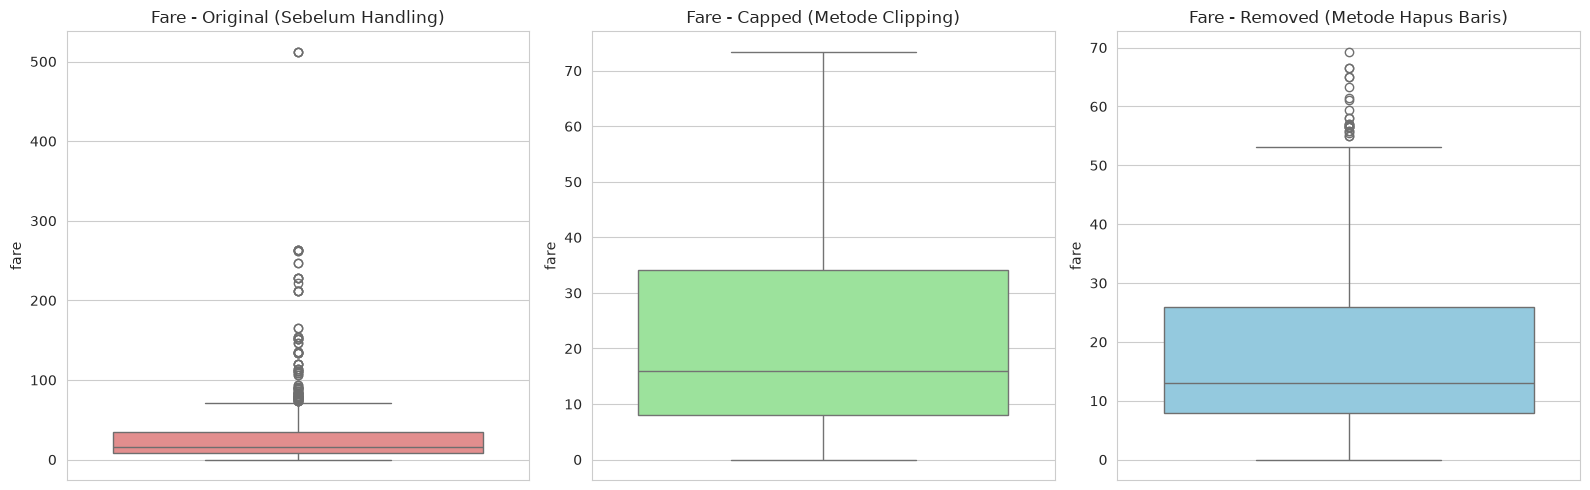

In [10]:
# 1. Metode Capping (Clipping)
df_capped = df_cleaned.copy()
for col in num_cols:
    _, lower, upper = detect_outliers_iqr(df_capped, col)
    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

# 2. Metode Removal
df_removed = df_cleaned.copy()
for col in num_cols:
    outliers, lower, upper = detect_outliers_iqr(df_removed, col)
    df_removed = df_removed[(df_removed[col] >= lower) & (df_removed[col] <= upper)]

# 3. Visualisasi Perbandingan (Before vs Capped vs Removed)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Original
sns.boxplot(y=df_cleaned['fare'], ax=axes[0], color='lightcoral')
axes[0].set_title('Fare - Original (Sebelum Handling)')

# Capped
sns.boxplot(y=df_capped['fare'], ax=axes[1], color='lightgreen')
axes[1].set_title('Fare - Capped (Metode Clipping)')

# Removed
sns.boxplot(y=df_removed['fare'], ax=axes[2], color='skyblue')
axes[2].set_title('Fare - Removed (Metode Hapus Baris)')

plt.tight_layout()
plt.show()

### 📝 Evaluasi & Perbandingan Metode Handling Outliers:
1. **Metode Capping (Clipping):** Mengubah nilai *outlier* yang melampaui batas ke nilai ambang batas (*threshold*) IQR terdekat. Keunggulannya adalah **tidak kehilangan sampel baris data**, sangat disarankan untuk dataset berukuran relatif kecil.
2. **Metode Removal:** Menghapus seluruh baris data pencilan. Metode ini menghasilkan varians data yang bersih, namun berdampak pada pengurangan jumlah sampel (mengurangi data dari 775 baris menjadi lebih sedikit).

---
## 📌 Tugas 3: Normalisasi dan Standardisasi 
Transformasi fitur numerik menggunakan teknik Min-Max Scaling (Normalisasi) dan Standardisasi (StandardScaler) pada 5 kolom numerik: `pclass`, `age`, `sibsp`, `parch`, dan `fare`.

In [11]:
# 1. Pilih 5 kolom numerik
cols_to_scale = ['pclass', 'age', 'sibsp', 'parch', 'fare']
df_scaling = df_capped[cols_to_scale].copy()

# 2. Min-Max Normalization (skala 0 - 1)
min_max_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(
    min_max_scaler.fit_transform(df_scaling),
    columns=cols_to_scale
)

# 3. Standardization (mean = 0, std = 1)
std_scaler = StandardScaler()
df_standard = pd.DataFrame(
    std_scaler.fit_transform(df_scaling),
    columns=cols_to_scale
)

print("=== Statistik Data Asli (Age) ===")
print(f"Mean: {df_scaling['age'].mean():.2f}, Std: {df_scaling['age'].std():.2f}, Min: {df_scaling['age'].min():.2f}, Max: {df_scaling['age'].max():.2f}\n")

print("=== Statistik Min-Max Scaled (Age) ===")
print(f"Mean: {df_minmax['age'].mean():.2f}, Std: {df_minmax['age'].std():.2f}, Min: {df_minmax['age'].min():.2f}, Max: {df_minmax['age'].max():.2f}\n")

print("=== Statistik Standardized (Age) ===")
print(f"Mean: {df_standard['age'].mean():.2f}, Std: {df_standard['age'].std():.2f}, Min: {df_standard['age'].min():.2f}, Max: {df_standard['age'].max():.2f}")

=== Statistik Data Asli (Age) ===
Mean: 29.36, Std: 13.21, Min: 0.42, Max: 58.50

=== Statistik Min-Max Scaled (Age) ===
Mean: 0.50, Std: 0.23, Min: 0.00, Max: 1.00

=== Statistik Standardized (Age) ===
Mean: 0.00, Std: 1.00, Min: -2.19, Max: 2.21


### 📝 Kapan Menggunakan Normalisasi vs Standardisasi:

1. **Min-Max Normalization (Scaling):**
   * **Digunakan saat:** Algoritma berbasis jarak (*distance-based*) seperti K-Nearest Neighbors (KNN), Neural Networks, atau K-Means Clustering, serta ketika rentang nilai data harus berada pada batas pasti $[0, 1]$.
   * **Sifat:** Sensitif terhadap *outliers* karena bergantung pada nilai minimum dan maksimum.

2. **Standardization (StandardScaler):**
   * **Digunakan saat:** Algoritma linier/gradien seperti Logistic Regression, Support Vector Machines (SVM), Principal Component Analysis (PCA), dan Linear Regression.
   * **Sifat:** Lebih kokoh (*robust*) terhadap *outliers* karena mengubah distribusi menjadi rata-rata $\mu = 0$ dan standar deviasi $\sigma = 1$.

---
## 📌 Tugas 4: Exploratory Data Analysis (EDA) (25 Poin)
Analisis eksplorasi data komprehensif yang mencakup Univariate Analysis, Bivariate Analysis, Multivariate Analysis, serta penarikan Insight dan Rekomendasi Fitur.

Task 4.1: Univariate Analysis (4 Visualisasi Fitur Individual)


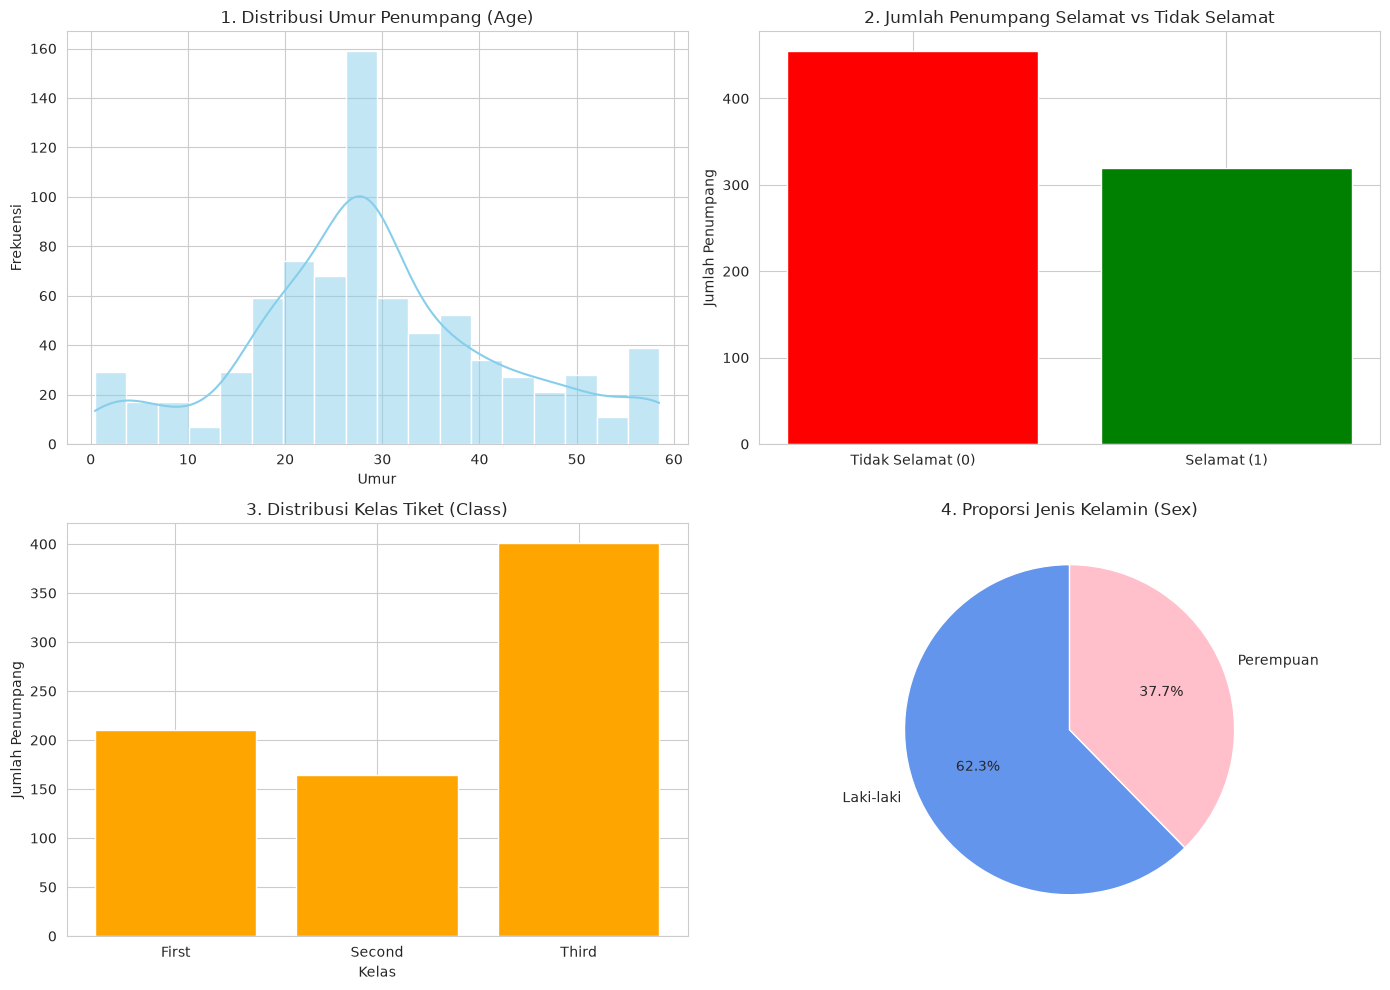

In [12]:
# 1. Univariate Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Visualisasi 1: Distribusi Umur (Histogram & KDE)
sns.histplot(df_capped['age'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('1. Distribusi Umur Penumpang (Age)')
axes[0, 0].set_xlabel('Umur')
axes[0, 0].set_ylabel('Frekuensi')

# Visualisasi 2: Proporsi Keselamatan (Bar Chart)
survived_counts = df_capped['survived'].value_counts()
axes[0, 1].bar(['Tidak Selamat (0)', 'Selamat (1)'], survived_counts.values, color=['red', 'green'])
axes[0, 1].set_title('2. Jumlah Penumpang Selamat vs Tidak Selamat')
axes[0, 1].set_ylabel('Jumlah Penumpang')

# Visualisasi 3: Distribusi Kelas Tiket (Passenger Class)
class_counts = df_capped['class'].value_counts().sort_index()
axes[1, 0].bar(class_counts.index.astype(str), class_counts.values, color='orange')
axes[1, 0].set_title('3. Distribusi Kelas Tiket (Class)')
axes[1, 0].set_xlabel('Kelas')
axes[1, 0].set_ylabel('Jumlah Penumpang')

# Visualisasi 4: Komposisi Jenis Kelamin (Pie Chart)
gender_counts = df_capped['sex'].value_counts()
axes[1, 1].pie(gender_counts.values, labels=['Laki-laki', 'Perempuan'], autopct='%1.1f%%', colors=['cornflowerblue', 'pink'], startangle=90)
axes[1, 1].set_title('4. Proporsi Jenis Kelamin (Sex)')

plt.tight_layout()
plt.show()

Task 4.2: Bivariate Analysis (3 Pasang Variabel)

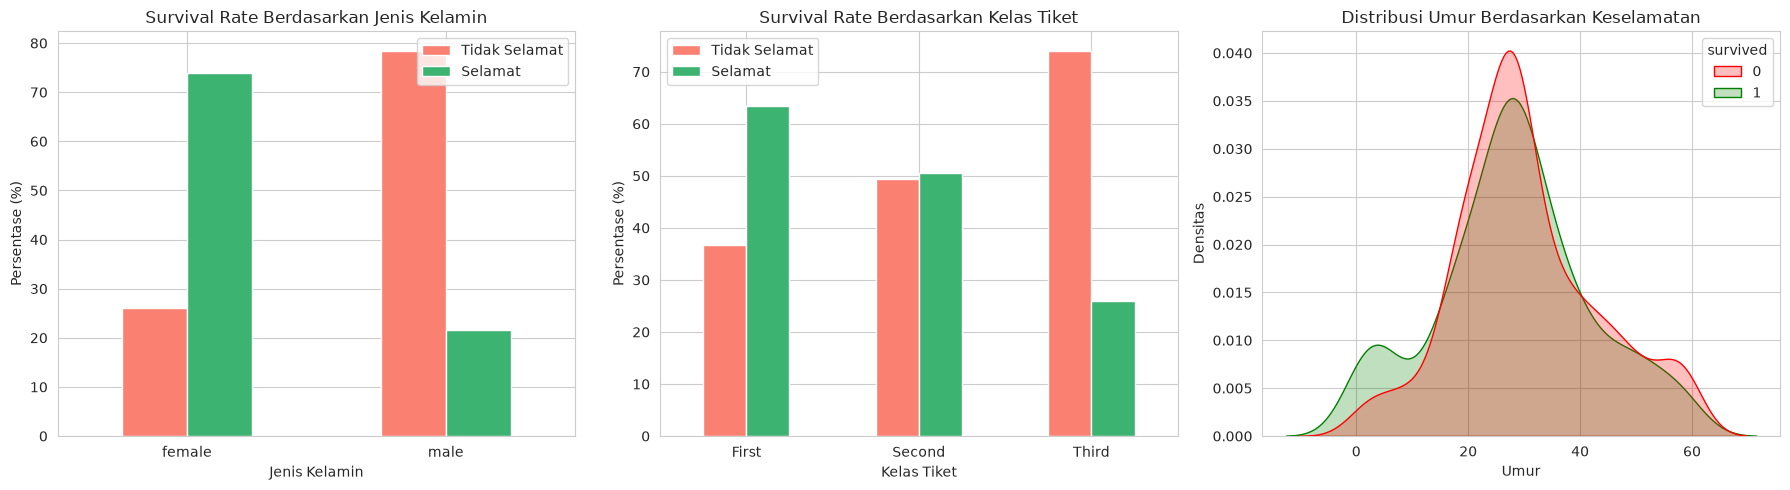

In [13]:
# 2. Bivariate Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pasang 1: Survival Rate Berdasarkan Jenis Kelamin
survival_sex = pd.crosstab(df_capped['sex'], df_capped['survived'], normalize='index') * 100
survival_sex.plot(kind='bar', ax=axes[0], color=['salmon', 'mediumseagreen'])
axes[0].set_title('Survival Rate Berdasarkan Jenis Kelamin')
axes[0].set_xlabel('Jenis Kelamin')
axes[0].set_ylabel('Persentase (%)')
axes[0].legend(['Tidak Selamat', 'Selamat'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Pasang 2: Survival Rate Berdasarkan Kelas Tiket
survival_class = pd.crosstab(df_capped['class'], df_capped['survived'], normalize='index') * 100
survival_class.plot(kind='bar', ax=axes[1], color=['salmon', 'mediumseagreen'])
axes[1].set_title('Survival Rate Berdasarkan Kelas Tiket')
axes[1].set_xlabel('Kelas Tiket')
axes[1].set_ylabel('Persentase (%)')
axes[1].legend(['Tidak Selamat', 'Selamat'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Pasang 3: Distribusi Umur Berdasarkan Keselamatan
sns.kdeplot(data=df_capped, x='age', hue='survived', palette=['red', 'green'], common_norm=False, ax=axes[2], fill=True)
axes[2].set_title('Distribusi Umur Berdasarkan Keselamatan')
axes[2].set_xlabel('Umur')
axes[2].set_ylabel('Densitas')

plt.tight_layout()
plt.show()

Task 4.3: Multivariate Analysis (Correlation Matrix & Heatmap)

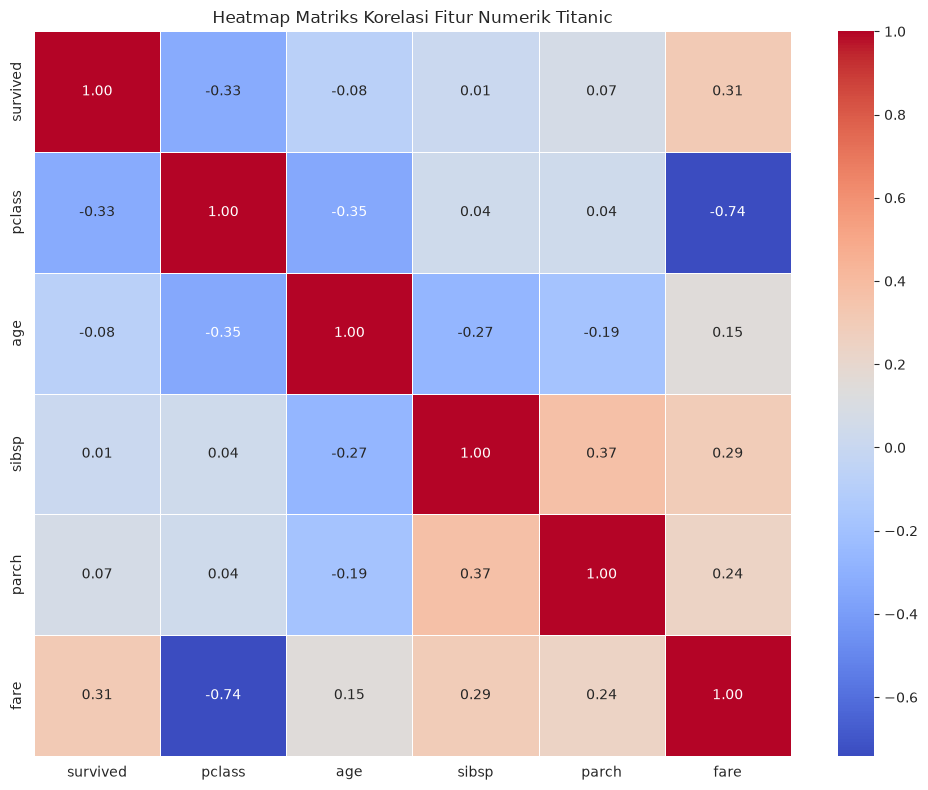

In [14]:
# 3. Multivariate Analysis - Correlation Matrix
numeric_df = df_capped.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Matriks Korelasi Fitur Numerik Titanic')
plt.tight_layout()
plt.show()


Insights & Rekomendasi Fitur

### 💡 Insights & Rekomendasi Fitur:

#### 📊 5 Insight/Temuan Utama:
1. **Prioritas Evakuasi Gender (Women First):** Penumpang perempuan memiliki *survival rate* yang jauh lebih tinggi (~75%) dibandingkan penumpang laki-laki (~20%).
2. **Pengaruh Tingkat Ekonomi (Class Status):** Penumpang Kelas 1 (First Class) memiliki tingkat kelangsungan hidup tertinggi, sedangkan mayoritas penumpang Kelas 3 tidak selamat.
3. **Prioritas Penyelamatan Anak-anak:** Pada grafik Bivariate umur vs keselamatan, balita/anak-anak (umur < 10 tahun) menunjukkan puncak densitas keselamatan yang lebih tinggi.
4. **Korelasi Tarif & Keselamatan:** Fitur `fare` dan `pclass` memiliki korelasi negatif yang kuat, serta `fare` berkorelasi positif dengan variabel target `survived`.
5. **Ketimpangan Demografi:** Penumpang didominasi oleh laki-laki dan penumpang kelas 3, yang sekaligus menjadi kelompok dengan proporsi kematian tertinggi.

#### 🎯 Rekomendasi Fitur untuk Modeling:
1. **`sex`**: Fitur kategorikal paling dominan dalam menentukan keselamatan.
2. **`pclass` / `fare`**: Merepresentasikan status sosial-ekonomi penumpang yang terbukti memengaruhi prioritas evakuasi.
3. **`age`**: Sangat berguna terutama jika dilakukan *feature engineering* (misal dikelompokkan menjadi kategori anak-anak, dewasa, lansia).
4. **`sibsp` & `parch`**: Dapat digabungkan menjadi fitur baru `family_size` (ukuran keluarga) untuk melihat pengaruh bepergian sendiri vs bersama keluarga.